# Data Visualization in Python

In [42]:
import pandas

# Import titanic dataset using Kaggle
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Titanic-Dataset.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "yasserh/titanic-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_18156/4110989114.py:11: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


First 5 records:    PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   

## MatPlotLib

In [43]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'Survival Rate')

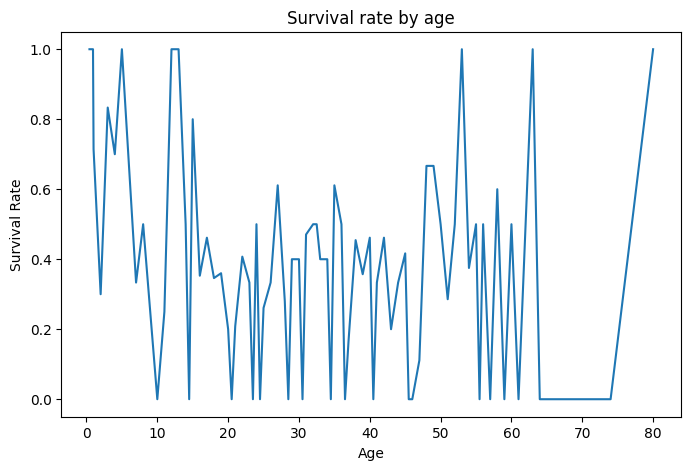

In [44]:
# Line chart

# Take the mean of survived (a binary variable) by age
avg_surv_rate_by_age = df.groupby("Age")["Survived"].mean()

# determines size of image displayed
plt.figure(figsize=(8,5))

# plots the line
plt.plot(avg_surv_rate_by_age)

# Title and axis labels
plt.title("Survival rate by age")
plt.xlabel("Age")
plt.ylabel("Survival Rate")

# displays the chart in the notebook


Text(0.5, 1.0, 'Age Distribution')

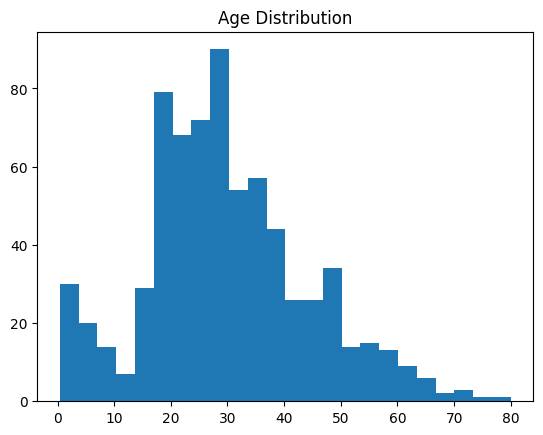

In [45]:
# Histogram
plt.hist(df["Age"], bins=24)

plt.title("Age Distribution")

(array([0, 1]), [Text(0, 0, 'female'), Text(1, 0, 'male')])

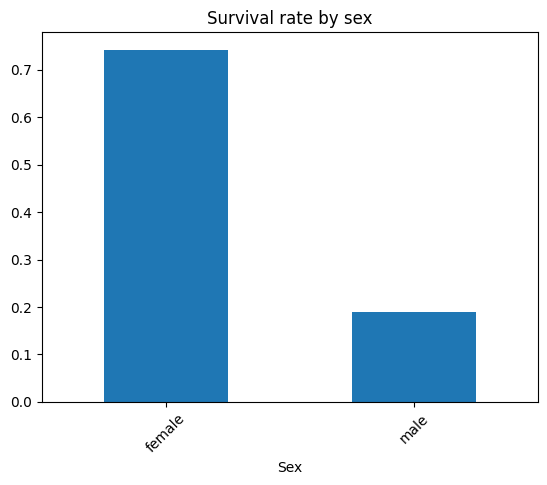

In [46]:
# Bar Chart
survival_by_sex = df.groupby("Sex")["Survived"].mean()

survival_by_sex.plot(kind="bar")

plt.title("Survival rate by sex")

plt.xticks(rotation=45)

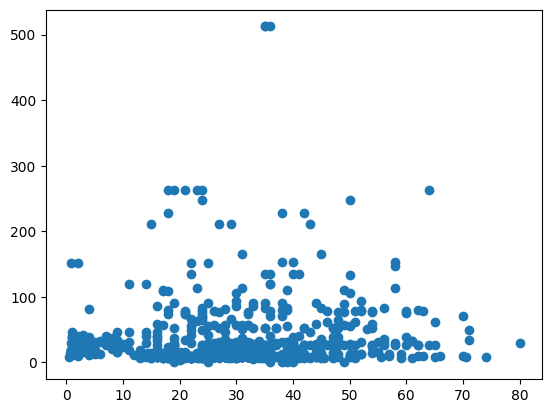

In [47]:
# Scatter Plot
plt.scatter(df["Age"], df["Fare"])

([<matplotlib.patches.Wedge at 0x71c10bedfce0>,
 [Text(-0.7128398816865827, 0.8377704357859967, 'S'),
  Text(0.4614526582133295, -0.9985296411363321, 'C'),
  Text(1.0595277266497123, -0.29563659526603386, 'Q')],
 [Text(-0.3888217536472269, 0.45696569224690725, '72.4%'),
  Text(0.2517014499345433, -0.5446525315289084, '18.9%'),
  Text(0.5779242145362067, -0.1612563246905639, '8.7%')])

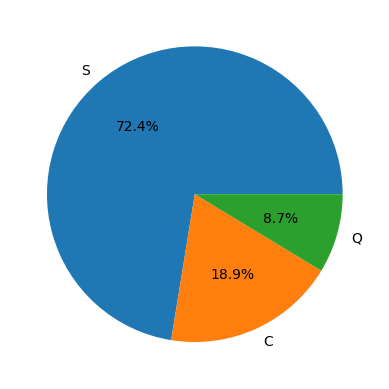

In [48]:
# Pie Chart
embarked_counts = df["Embarked"].value_counts()

plt.pie(embarked_counts, labels=embarked_counts.index, autopct = "%1.1f%%")

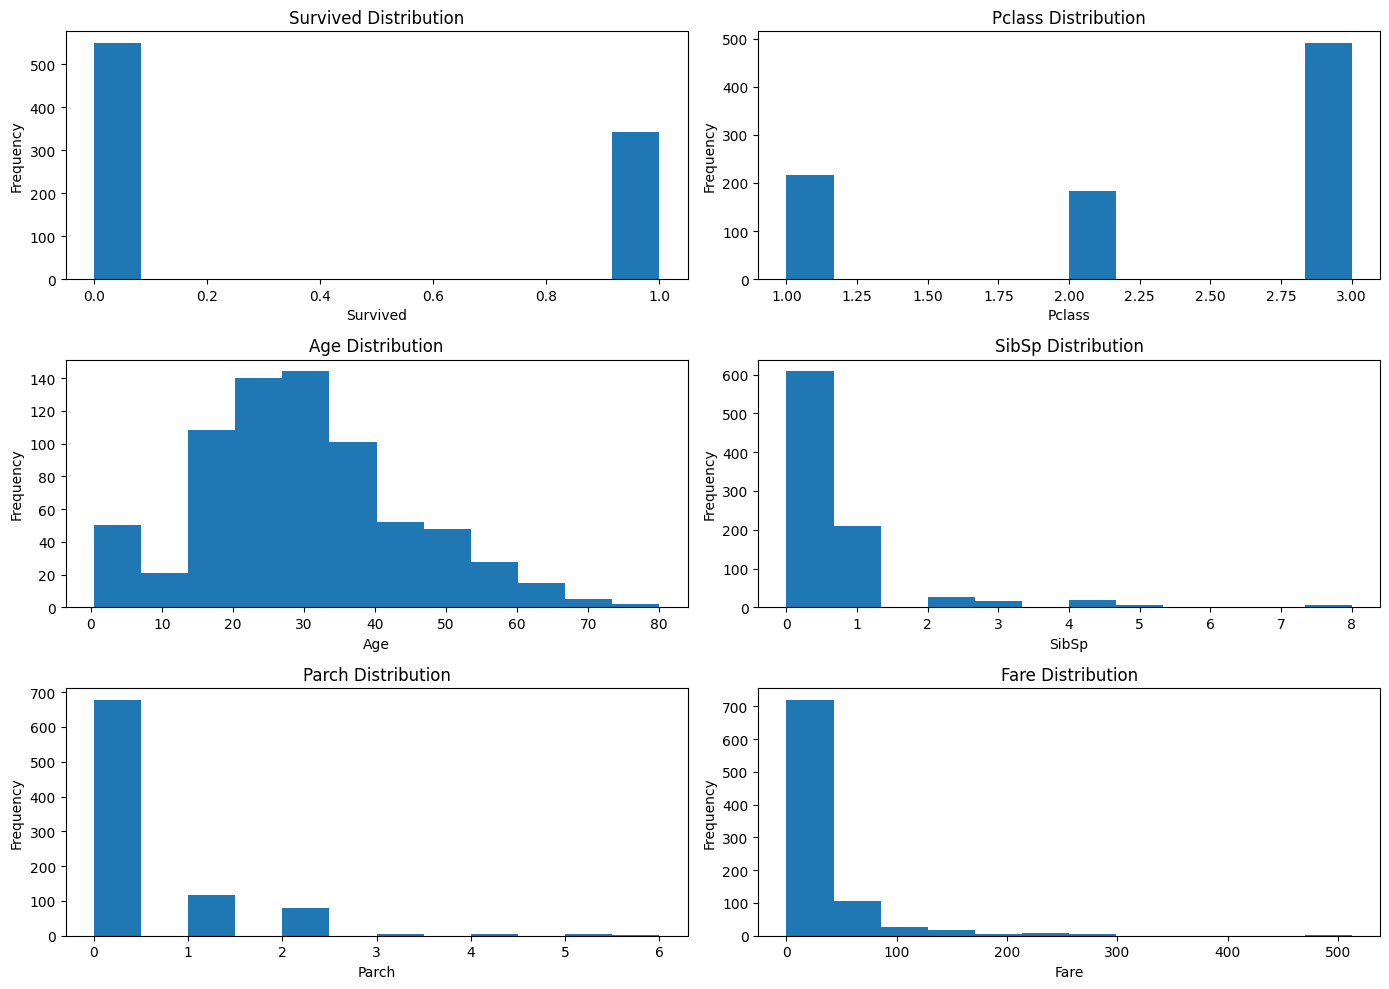

In [50]:
# sub plots
numeric_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

# create all histogram subplots
for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=12)
    axes[i].set_title(f"{col} Distribution")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## Advanced Visualizations with Seaborn

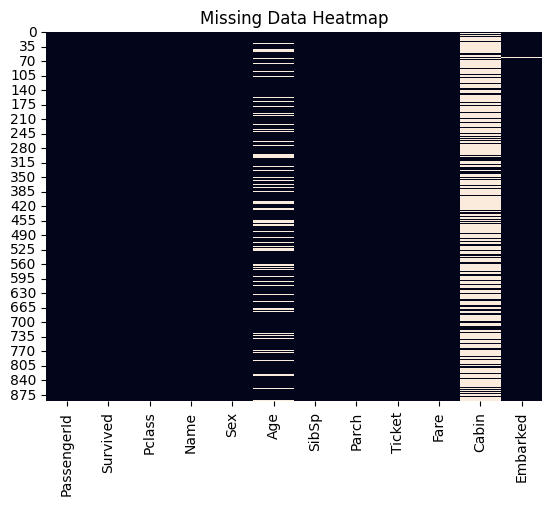

In [51]:
import seaborn as sns

sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Data Heatmap")
plt.show()

In [ ]:
# plot data missingness


In [ ]:
# correlation heatmap



In [ ]:
# pair plot


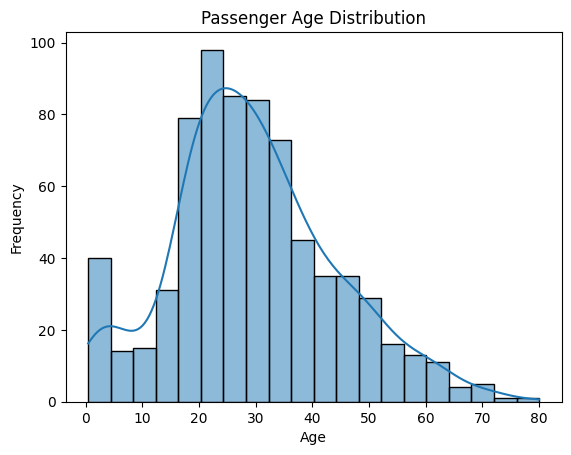

In [52]:
# Cleaner versions of basic charts (histogram)
sns.histplot(df['Age'], kde=True)

plt.title("Passenger Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

In [ ]:
# scatterplot with a fitted line in seaborn


# Logistic Regression

In [ ]:
import statsmodels.api as sm

# Drop rows with missing 'Age' values to avoid NaNs in the model
df_cleaned = df.dropna(subset=['Age']).copy()

# Define the dependent variable (y) and independent variables (X)
y = df_cleaned['Survived']
X = df_cleaned[['Age', 'Fare', 'Pclass', 'SibSp', 'Parch']]

# Add a constant to the independent variables matrix
X = sm.add_constant(X)

# Create and fit the logistic regression model
logit_model = sm.Logit(y, X)
result = logit_model.fit()

# Display the model summary
print(result.summary())

ModuleNotFoundError: No module named 'statsmodels'

Confusion Matrix:
[[351  73]
 [140 150]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.83      0.77       424
           1       0.67      0.52      0.58       290

    accuracy                           0.70       714
   macro avg       0.69      0.67      0.68       714
weighted avg       0.70      0.70      0.69       714



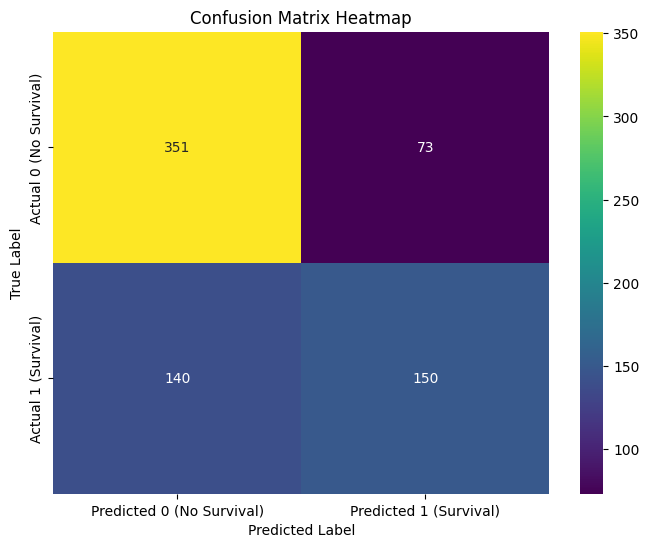

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Get predicted probabilities
predictions = result.predict(X)

# Convert probabilities to binary predictions (0 or 1) using a threshold of 0.5
y_pred = (predictions > 0.5).astype(int)

# Calculate the confusion matrix
cm = confusion_matrix(y, y_pred)

print("Confusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y, y_pred))

# Visualize the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='viridis',
    xticklabels=['Predicted 0 (No Survival)', 'Predicted 1 (Survival)'],
    yticklabels=['Actual 0 (No Survival)', 'Actual 1 (Survival)']
)

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()